# INDIAN STARTUP FUNDING

## Introduction

**Project Objective**

The objective of this project is to analyze Indian startup funding data to understand funding trends, popular industries, major investors, and key startup hubs in India.

**Project Definition**

This project analyzes a dataset containing funding details of Indian startups, including funding date, city, investors, industry, and amount invested. The analysis focuses on identifying patterns in startup funding over time, the most funded sectors and cities, and the role of major investors in the Indian startup ecosystem.

**Dataset**

This dataset contains funding information for Indian startups, includes details such as the funding date, the city where the startup is based, the names of the investors, and the amount invested (in USD).

**Libraries**

First of all, we import the necessary Python libraries for data manipulation, numerical computations, and data visualization. These libraries provide essential tools for exploring, cleaning, and visualizing the dataset efficiently. 

- **pandas** is used for data loading and manipulation.
- **numpy** supports numerical operations.
- **matplotlib**, **plotly** and **seaborn** are used for data visualization and plotting. 

In [100]:
pip install pandas

In [101]:
import pandas as pd

In [102]:
import numpy as np

In [103]:
import matplotlib.pyplot as plt

In [104]:
pip install seaborn

In [105]:
import seaborn as sns
sns.set_theme()   #it makes plots look nicer by default

In [106]:
pip install plotly

Note: you may need to restart the kernel to use updated packages.


In [107]:
import plotly.express as px

## 1. Data Loading and Initial Overview

### 1.1 Loading the Dataset

We start by loading the dataset using **pandas**. 

In [108]:
df = pd.read_csv("Indian Startup Funding.csv")
df

,Sr_No,Date_dd/mm/yyyy,Startup_Name,Industry_Vertical,SubVertical,City__Location,Investors_Name,InvestmentnType,Amount_in_USD,Remarks
0,1,09-01-2020,BYJUâ€™S,E-Tech,E-learning,Bengaluru,Tiger Global Management,Private Equity Round,"20,00,00,000",?
1,2,13-01-2020,Shuttl,Transportation,App based shuttle service,Gurgaon,Susquehanna Growth Equity,Series C,"80,48,394",?
2,3,09-01-2020,Mamaearth,E-commerce,Retailer of baby and toddler products,Bengaluru,Sequoia Capital India,Series B,"1,83,58,860",?
3,4,02-01-2020,https://www.wealthbucket.in/,FinTech,Online Investment,New Delhi,Vinod Khatumal,Pre-series A,"30,00,000",?
4,5,02-01-2020,Fashor,Fashion and Apparel,Embroiled Clothes For Women,Mumbai,Sprout Venture Partners,Seed Round,"18,00,000",?
...,...,...,...,...,...,...,...,...,...,...
3039,3040,29-01-2015,Printvenue,?,?,?,Asia Pacific Internet Group,Private Equity,"45,00,000",?
3040,3041,29-01-2015,Graphene,?,?,?,KARSEMVEN Fund,Private Equity,"8,25,000",Govt backed VC Fund
3041,3042,30-01-2015,Mad Street Den,?,?,?,"Exfinity Fund, GrowX Ventures.",Private Equity,"15,00,000",?
3042,3043,30-01-2015,Simplotel,?,?,?,MakeMyTrip,Private Equity,?,"Strategic Funding, Minority stake"


### 1.2  Initial Overview

Now we can provide an overview of the dataset. 

**1.2.(a) Number of rows and columns**

By using **df.shape**, it returns a tuple: (rows, columns). Then we extract the number of rows and columns from it. 

In [109]:
print(df.shape)
print("Rows:",df.shape[0])
print("Columns:",df.shape[1])

(3044, 10)
Rows: 3044
Columns: 10


We can see that the dataset has 3044 rows and 10 columns. 

**1.2.(b) Data types of each column**

Using **df.dtypes**, we get

In [110]:
print(df.dtypes)

Sr_No                 int64
Date_dd/mm/yyyy      object
Startup_Name         object
Industry_Vertical    object
SubVertical          object
City__Location       object
Investors_Name       object
InvestmentnType      object
Amount_in_USD        object
Remarks              object
dtype: object


**1.2.(c) Initial observations**

Now we look onto some initial observations using **head()**, **info()** & **describe()**. 

- **head()** shows the first 5 rows of your dataset (default).
- **info()** provides summary information about the dataset.
- **describe()** provides statistical summary for numeric columns by default. 

In [111]:
df.head()

,Sr_No,Date_dd/mm/yyyy,Startup_Name,Industry_Vertical,SubVertical,City__Location,Investors_Name,InvestmentnType,Amount_in_USD,Remarks
0,1,09-01-2020,BYJUâ€™S,E-Tech,E-learning,Bengaluru,Tiger Global Management,Private Equity Round,"20,00,00,000",?
1,2,13-01-2020,Shuttl,Transportation,App based shuttle service,Gurgaon,Susquehanna Growth Equity,Series C,"80,48,394",?
2,3,09-01-2020,Mamaearth,E-commerce,Retailer of baby and toddler products,Bengaluru,Sequoia Capital India,Series B,"1,83,58,860",?
3,4,02-01-2020,https://www.wealthbucket.in/,FinTech,Online Investment,New Delhi,Vinod Khatumal,Pre-series A,"30,00,000",?
4,5,02-01-2020,Fashor,Fashion and Apparel,Embroiled Clothes For Women,Mumbai,Sprout Venture Partners,Seed Round,"18,00,000",?


In [112]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3044 entries, 0 to 3043
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Sr_No              3044 non-null   int64 
 1   Date_dd/mm/yyyy    3044 non-null   object
 2   Startup_Name       3044 non-null   object
 3   Industry_Vertical  3044 non-null   object
 4   SubVertical        3044 non-null   object
 5   City__Location     3044 non-null   object
 6   Investors_Name     3044 non-null   object
 7   InvestmentnType    3044 non-null   object
 8   Amount_in_USD      3040 non-null   object
 9   Remarks            3044 non-null   object
dtypes: int64(1), object(9)
memory usage: 237.9+ KB


In [113]:
df.describe()

,Sr_No
count,3044.000000
mean,1522.500000
std,878.871435
min,1.000000
25%,761.750000
50%,1522.500000
75%,2283.250000
max,3044.000000


## 2. Data Pre-processing 

Now we perform all the necessary cleaning steps. 

### 2.1 Removing Duplicates

First we look for any duplicate rows, using **df.duplicated()**. 

In [114]:
duplicates = df.duplicated()
print("Total number of duplicate rows:", duplicates.sum())  # total number of duplicate rows

Total number of duplicate rows: 0


We found 0 duplicate rows, so the dataset now contains only unique entries. 

### 2.2 Correcting Data Types 

Earlier in **1.2.(b)** we found that the data type of the column "Amount_in_USD" as object. Before we convert it into as float, if we have commas, currency symbols, spaces,...etc, cleaning it first helps a lot. 

In [115]:
df["Amount_in_USD_Clean"] = (
    df["Amount_in_USD"]
      .astype(str)
      .str.replace(",", "", regex=False)
      .str.replace("$", "", regex=False)
      .str.strip()
)

In [116]:
df

,Sr_No,Date_dd/mm/yyyy,Startup_Name,Industry_Vertical,SubVertical,City__Location,Investors_Name,InvestmentnType,Amount_in_USD,Remarks,Amount_in_USD_Clean
0,1,09-01-2020,BYJUâ€™S,E-Tech,E-learning,Bengaluru,Tiger Global Management,Private Equity Round,"20,00,00,000",?,200000000
1,2,13-01-2020,Shuttl,Transportation,App based shuttle service,Gurgaon,Susquehanna Growth Equity,Series C,"80,48,394",?,8048394
2,3,09-01-2020,Mamaearth,E-commerce,Retailer of baby and toddler products,Bengaluru,Sequoia Capital India,Series B,"1,83,58,860",?,18358860
3,4,02-01-2020,https://www.wealthbucket.in/,FinTech,Online Investment,New Delhi,Vinod Khatumal,Pre-series A,"30,00,000",?,3000000
4,5,02-01-2020,Fashor,Fashion and Apparel,Embroiled Clothes For Women,Mumbai,Sprout Venture Partners,Seed Round,"18,00,000",?,1800000
...,...,...,...,...,...,...,...,...,...,...,...
3039,3040,29-01-2015,Printvenue,?,?,?,Asia Pacific Internet Group,Private Equity,"45,00,000",?,4500000
3040,3041,29-01-2015,Graphene,?,?,?,KARSEMVEN Fund,Private Equity,"8,25,000",Govt backed VC Fund,825000
3041,3042,30-01-2015,Mad Street Den,?,?,?,"Exfinity Fund, GrowX Ventures.",Private Equity,"15,00,000",?,1500000
3042,3043,30-01-2015,Simplotel,?,?,?,MakeMyTrip,Private Equity,?,"Strategic Funding, Minority stake",?


Now we convert it into float. 

In [117]:
df["Amount_in_USD_Clean"] = pd.to_numeric(df["Amount_in_USD_Clean"], errors="coerce")   # converts ?, empty strings, bad text into NaN

In [118]:
df

,Sr_No,Date_dd/mm/yyyy,Startup_Name,Industry_Vertical,SubVertical,City__Location,Investors_Name,InvestmentnType,Amount_in_USD,Remarks,Amount_in_USD_Clean
0,1,09-01-2020,BYJUâ€™S,E-Tech,E-learning,Bengaluru,Tiger Global Management,Private Equity Round,"20,00,00,000",?,200000000.0
1,2,13-01-2020,Shuttl,Transportation,App based shuttle service,Gurgaon,Susquehanna Growth Equity,Series C,"80,48,394",?,8048394.0
2,3,09-01-2020,Mamaearth,E-commerce,Retailer of baby and toddler products,Bengaluru,Sequoia Capital India,Series B,"1,83,58,860",?,18358860.0
3,4,02-01-2020,https://www.wealthbucket.in/,FinTech,Online Investment,New Delhi,Vinod Khatumal,Pre-series A,"30,00,000",?,3000000.0
4,5,02-01-2020,Fashor,Fashion and Apparel,Embroiled Clothes For Women,Mumbai,Sprout Venture Partners,Seed Round,"18,00,000",?,1800000.0
...,...,...,...,...,...,...,...,...,...,...,...
3039,3040,29-01-2015,Printvenue,?,?,?,Asia Pacific Internet Group,Private Equity,"45,00,000",?,4500000.0
3040,3041,29-01-2015,Graphene,?,?,?,KARSEMVEN Fund,Private Equity,"8,25,000",Govt backed VC Fund,825000.0
3041,3042,30-01-2015,Mad Street Den,?,?,?,"Exfinity Fund, GrowX Ventures.",Private Equity,"15,00,000",?,1500000.0
3042,3043,30-01-2015,Simplotel,?,?,?,MakeMyTrip,Private Equity,?,"Strategic Funding, Minority stake",NaN


Now we move to the column "Date_dd/mm/yyyy". 

In [119]:
df["Date"] = (
    df["Date_dd/mm/yyyy"]
      .astype(str)
      .str.strip()                 # remove leading/trailing spaces
)

df["Date"] = pd.to_datetime(df["Date"], dayfirst=True, errors="coerce")

In [120]:
df

,Sr_No,Date_dd/mm/yyyy,Startup_Name,Industry_Vertical,SubVertical,City__Location,Investors_Name,InvestmentnType,Amount_in_USD,Remarks,Amount_in_USD_Clean,Date
0,1,09-01-2020,BYJUâ€™S,E-Tech,E-learning,Bengaluru,Tiger Global Management,Private Equity Round,"20,00,00,000",?,200000000.0,2020-01-09
1,2,13-01-2020,Shuttl,Transportation,App based shuttle service,Gurgaon,Susquehanna Growth Equity,Series C,"80,48,394",?,8048394.0,2020-01-13
2,3,09-01-2020,Mamaearth,E-commerce,Retailer of baby and toddler products,Bengaluru,Sequoia Capital India,Series B,"1,83,58,860",?,18358860.0,2020-01-09
3,4,02-01-2020,https://www.wealthbucket.in/,FinTech,Online Investment,New Delhi,Vinod Khatumal,Pre-series A,"30,00,000",?,3000000.0,2020-01-02
4,5,02-01-2020,Fashor,Fashion and Apparel,Embroiled Clothes For Women,Mumbai,Sprout Venture Partners,Seed Round,"18,00,000",?,1800000.0,2020-01-02
...,...,...,...,...,...,...,...,...,...,...,...,...
3039,3040,29-01-2015,Printvenue,?,?,?,Asia Pacific Internet Group,Private Equity,"45,00,000",?,4500000.0,2015-01-29
3040,3041,29-01-2015,Graphene,?,?,?,KARSEMVEN Fund,Private Equity,"8,25,000",Govt backed VC Fund,825000.0,2015-01-29
3041,3042,30-01-2015,Mad Street Den,?,?,?,"Exfinity Fund, GrowX Ventures.",Private Equity,"15,00,000",?,1500000.0,2015-01-30
3042,3043,30-01-2015,Simplotel,?,?,?,MakeMyTrip,Private Equity,?,"Strategic Funding, Minority stake",NaN,2015-01-30


In [121]:
df.dtypes

Sr_No                           int64
Date_dd/mm/yyyy                object
Startup_Name                   object
Industry_Vertical              object
SubVertical                    object
City__Location                 object
Investors_Name                 object
InvestmentnType                object
Amount_in_USD                  object
Remarks                        object
Amount_in_USD_Clean           float64
Date                   datetime64[ns]
dtype: object

By comparing the data types of the columns "Date_dd/mm/yyyy" and "Amount_in_USD" to "Date" and "Amount_in_USD_Clean" respectively, you can see the dfference. 

### 2.3 Handling Missing Values

Now we replace misiing values in the column "Amount_in_USD_Clean" with avaerage, using **fillna()**. 

In [122]:
df["Amount_in_USD_Clean"] = df["Amount_in_USD_Clean"].fillna(df["Amount_in_USD_Clean"].mean())


In [123]:
df

,Sr_No,Date_dd/mm/yyyy,Startup_Name,Industry_Vertical,SubVertical,City__Location,Investors_Name,InvestmentnType,Amount_in_USD,Remarks,Amount_in_USD_Clean,Date
0,1,09-01-2020,BYJUâ€™S,E-Tech,E-learning,Bengaluru,Tiger Global Management,Private Equity Round,"20,00,00,000",?,2.000000e+08,2020-01-09
1,2,13-01-2020,Shuttl,Transportation,App based shuttle service,Gurgaon,Susquehanna Growth Equity,Series C,"80,48,394",?,8.048394e+06,2020-01-13
2,3,09-01-2020,Mamaearth,E-commerce,Retailer of baby and toddler products,Bengaluru,Sequoia Capital India,Series B,"1,83,58,860",?,1.835886e+07,2020-01-09
3,4,02-01-2020,https://www.wealthbucket.in/,FinTech,Online Investment,New Delhi,Vinod Khatumal,Pre-series A,"30,00,000",?,3.000000e+06,2020-01-02
4,5,02-01-2020,Fashor,Fashion and Apparel,Embroiled Clothes For Women,Mumbai,Sprout Venture Partners,Seed Round,"18,00,000",?,1.800000e+06,2020-01-02
...,...,...,...,...,...,...,...,...,...,...,...,...
3039,3040,29-01-2015,Printvenue,?,?,?,Asia Pacific Internet Group,Private Equity,"45,00,000",?,4.500000e+06,2015-01-29
3040,3041,29-01-2015,Graphene,?,?,?,KARSEMVEN Fund,Private Equity,"8,25,000",Govt backed VC Fund,8.250000e+05,2015-01-29
3041,3042,30-01-2015,Mad Street Den,?,?,?,"Exfinity Fund, GrowX Ventures.",Private Equity,"15,00,000",?,1.500000e+06,2015-01-30
3042,3043,30-01-2015,Simplotel,?,?,?,MakeMyTrip,Private Equity,?,"Strategic Funding, Minority stake",1.840230e+07,2015-01-30


Now in the dataset, we can see that missing values are denoted in "?". So the first step is to convert them into proper missing values, and then decide how to handle them. We use **df.replace()**. 

In [124]:
df = df.replace("?", np.nan)

In [125]:
df

,Sr_No,Date_dd/mm/yyyy,Startup_Name,Industry_Vertical,SubVertical,City__Location,Investors_Name,InvestmentnType,Amount_in_USD,Remarks,Amount_in_USD_Clean,Date
0,1,09-01-2020,BYJUâ€™S,E-Tech,E-learning,Bengaluru,Tiger Global Management,Private Equity Round,"20,00,00,000",NaN,2.000000e+08,2020-01-09
1,2,13-01-2020,Shuttl,Transportation,App based shuttle service,Gurgaon,Susquehanna Growth Equity,Series C,"80,48,394",NaN,8.048394e+06,2020-01-13
2,3,09-01-2020,Mamaearth,E-commerce,Retailer of baby and toddler products,Bengaluru,Sequoia Capital India,Series B,"1,83,58,860",NaN,1.835886e+07,2020-01-09
3,4,02-01-2020,https://www.wealthbucket.in/,FinTech,Online Investment,New Delhi,Vinod Khatumal,Pre-series A,"30,00,000",NaN,3.000000e+06,2020-01-02
4,5,02-01-2020,Fashor,Fashion and Apparel,Embroiled Clothes For Women,Mumbai,Sprout Venture Partners,Seed Round,"18,00,000",NaN,1.800000e+06,2020-01-02
...,...,...,...,...,...,...,...,...,...,...,...,...
3039,3040,29-01-2015,Printvenue,NaN,NaN,NaN,Asia Pacific Internet Group,Private Equity,"45,00,000",NaN,4.500000e+06,2015-01-29
3040,3041,29-01-2015,Graphene,NaN,NaN,NaN,KARSEMVEN Fund,Private Equity,"8,25,000",Govt backed VC Fund,8.250000e+05,2015-01-29
3041,3042,30-01-2015,Mad Street Den,NaN,NaN,NaN,"Exfinity Fund, GrowX Ventures.",Private Equity,"15,00,000",NaN,1.500000e+06,2015-01-30
3042,3043,30-01-2015,Simplotel,NaN,NaN,NaN,MakeMyTrip,Private Equity,NaN,"Strategic Funding, Minority stake",1.840230e+07,2015-01-30


Let us check how many missing values are there using **.isnull()**. 

In [126]:
df.isnull().sum()

Sr_No                     0
Date_dd/mm/yyyy           0
Startup_Name              0
Industry_Vertical       171
SubVertical             936
City__Location          180
Investors_Name           24
InvestmentnType           4
Amount_in_USD           964
Remarks                2625
Amount_in_USD_Clean       0
Date                      7
dtype: int64

So we fill the missing values in the columns "Industry_Vertical", "SubVertical", "City__Location", "Investors_Name", "InvestmentnType" and "Remarks" with "No Mention". Also missing values in "Date" column with "2015-01-01". 

In [127]:
df["Date"] = df["Date"].fillna(pd.Timestamp("2015-01-01"))

In [128]:
Columns = ["Industry_Vertical", "SubVertical", "City__Location", "Investors_Name", "InvestmentnType", "Remarks"]  # to replace multiple columns in a single step
df[Columns] = df[Columns].fillna("No Mention")

Now let us see how it went. 

In [129]:
df.isnull().sum()

Sr_No                    0
Date_dd/mm/yyyy          0
Startup_Name             0
Industry_Vertical        0
SubVertical              0
City__Location           0
Investors_Name           0
InvestmentnType          0
Amount_in_USD          964
Remarks                  0
Amount_in_USD_Clean      0
Date                     0
dtype: int64

Here you can see that we replaced missing values succsssfully. Note that we have an alternate column for "Amount_in_USD", which is "Amount_in_USD_Clean". 

### 2.4 Creating Derived Columns

We can create a column "Category" based on "Amount_in_USD_Clean", Which separates each company into "Tier-1", "Tier-2" and "Tier-3". First we check whats the maximum and minimum value in "Amount_in_USD_Clean". 

In [130]:
max_amnt = df["Amount_in_USD_Clean"].max()  # Maximum Amount
min_amnt = df["Amount_in_USD_Clean"].min()  # Minimum Amount

print("Maximum Amount:", max_amnt)
print("Minimum Amount:", min_amnt)

Maximum Amount: 3900000000.0
Minimum Amount: 16000.0


Therefore, 
- Tier-1: >=2000000000
- Tier-2: >=1000000000
- Tier-3: else

In [131]:
def categorize(amount):                                         # create a function
    if amount >= 2000000000:
        return "Tier-1"
    elif amount >= 1000000000:
        return "Tier-2"
    else:
        return "Tier-3"

df["Category"] = df["Amount_in_USD_Clean"].apply(categorize)   # applies the function to each row of the "Amount_in_USD_Clean" column. 

In [132]:
df

,Sr_No,Date_dd/mm/yyyy,Startup_Name,Industry_Vertical,SubVertical,City__Location,Investors_Name,InvestmentnType,Amount_in_USD,Remarks,Amount_in_USD_Clean,Date,Category
0,1,09-01-2020,BYJUâ€™S,E-Tech,E-learning,Bengaluru,Tiger Global Management,Private Equity Round,"20,00,00,000",No Mention,2.000000e+08,2020-01-09,Tier-3
1,2,13-01-2020,Shuttl,Transportation,App based shuttle service,Gurgaon,Susquehanna Growth Equity,Series C,"80,48,394",No Mention,8.048394e+06,2020-01-13,Tier-3
2,3,09-01-2020,Mamaearth,E-commerce,Retailer of baby and toddler products,Bengaluru,Sequoia Capital India,Series B,"1,83,58,860",No Mention,1.835886e+07,2020-01-09,Tier-3
3,4,02-01-2020,https://www.wealthbucket.in/,FinTech,Online Investment,New Delhi,Vinod Khatumal,Pre-series A,"30,00,000",No Mention,3.000000e+06,2020-01-02,Tier-3
4,5,02-01-2020,Fashor,Fashion and Apparel,Embroiled Clothes For Women,Mumbai,Sprout Venture Partners,Seed Round,"18,00,000",No Mention,1.800000e+06,2020-01-02,Tier-3
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3039,3040,29-01-2015,Printvenue,No Mention,No Mention,No Mention,Asia Pacific Internet Group,Private Equity,"45,00,000",No Mention,4.500000e+06,2015-01-29,Tier-3
3040,3041,29-01-2015,Graphene,No Mention,No Mention,No Mention,KARSEMVEN Fund,Private Equity,"8,25,000",Govt backed VC Fund,8.250000e+05,2015-01-29,Tier-3
3041,3042,30-01-2015,Mad Street Den,No Mention,No Mention,No Mention,"Exfinity Fund, GrowX Ventures.",Private Equity,"15,00,000",No Mention,1.500000e+06,2015-01-30,Tier-3
3042,3043,30-01-2015,Simplotel,No Mention,No Mention,No Mention,MakeMyTrip,Private Equity,NaN,"Strategic Funding, Minority stake",1.840230e+07,2015-01-30,Tier-3


### 2.5 Filtering or Aggregating Data

**2.5.(a) Filtering based on"Category"**

Filter rows where "Category" is "Tier-2". 

In [133]:
filtered_t2 = df[df["Category"] == "Tier-2"]
filtered_t2

,Sr_No,Date_dd/mm/yyyy,Startup_Name,Industry_Vertical,SubVertical,City__Location,Investors_Name,InvestmentnType,Amount_in_USD,Remarks,Amount_in_USD_Clean,Date,Category
31,32,25-11-2019,Paytm,FinTech,Mobile Wallet,Noida,Vijay Shekhar Sharma,Funding Round,"1,00,00,00,000",No Mention,1.000000e+09,2019-11-25,Tier-2
830,831,18-05-2017,Paytm,ECommerce,Mobile Wallet & ECommerce platform,Bangalore,SoftBank Group,Private Equity,"1,40,00,00,000",No Mention,1.400000e+09,2017-05-18,Tier-2
966,967,21-03-2017,Flipkart,eCommerce,ECommerce Marketplace,Bangalore,"Microsoft, eBay, Tencent Holdings",Private Equity,"1,40,00,00,000",No Mention,1.400000e+09,2017-03-21,Tier-2


**2.5.(b) Aggregation**

Next we calculate the sum of "Amount_in_USD_Clean" by grouping the "Category" column. 

In [134]:
agg_sum = df.groupby("Category")["Amount_in_USD_Clean"].sum().reset_index()
agg_sum

,Category,Amount_in_USD_Clean
0,Tier-1,6.400000e+09
1,Tier-2,3.800000e+09
2,Tier-3,4.581661e+10


## 3. EDA & Visualizations

Exploratory Data Analysis (EDA) and visualizations help understand the data by identifying patterns, trends, and outliers using simple charts and graphs.

### 3.1 Descriptive Statistics (Statistical Summary)

Descriptive Statistics (also called a Statistical Summary) are methods used to organize, summarize and describe main features of a dataset. For the Column "Amount_in_USD_Clean", using **describe()** we get

In [135]:
df[["Amount_in_USD_Clean"]].describe()

,Amount_in_USD_Clean
count,3.044000e+03
mean,1.840230e+07
std,9.996176e+07
min,1.600000e+04
25%,1.000000e+06
50%,7.200000e+06
75%,1.840230e+07
max,3.900000e+09


### 3.2 Univariate Analysis

Univariate analysis is the analysis of one variable at a time. 

**3.2.(a) Funding amount distribution**

Using **Seaborn** and through a histogram, we can view the funding amount distribution. 

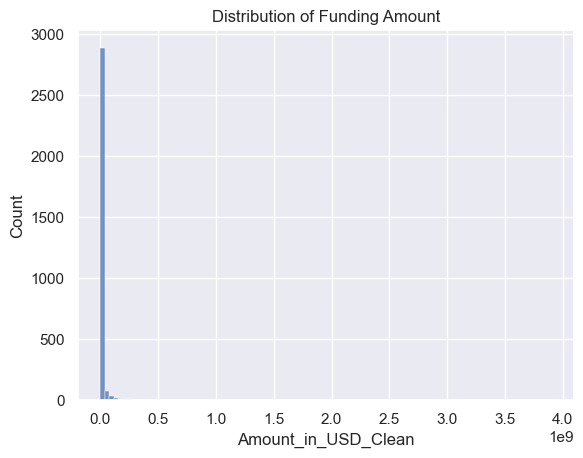

In [136]:
sns.histplot(df["Amount_in_USD_Clean"], bins = 100)   # create a histogram. 
plt.title("Distribution of Funding Amount")           # title for the graph. 
plt.show()                                            # visualization. 

**3.2.(b) Top industries**

By the help of a bar chart, we can see which are the top 5 industries. 

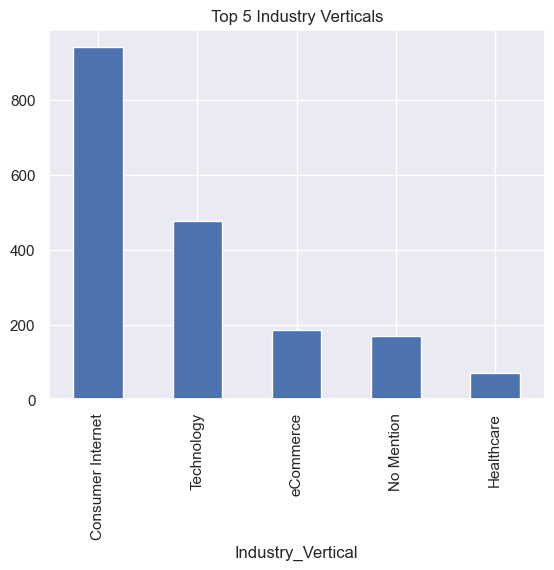

In [137]:
df["Industry_Vertical"].value_counts().head(5).plot(kind="bar")  # create a bar chart with top 5 values. 
plt.title("Top 5 Industry Verticals")
plt.show()

**3.2.(c) Investment types**

A pie chart to visualize the investment type distribution. 

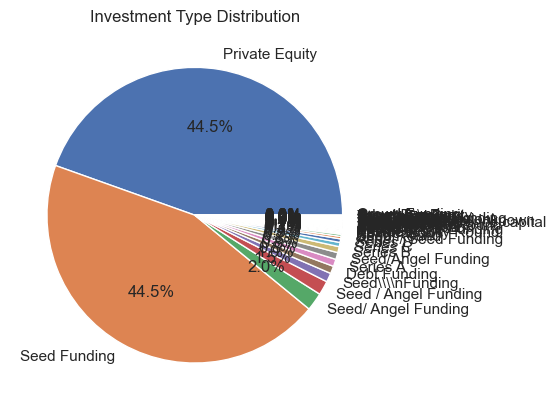

In [138]:
value=df["InvestmentnType"].value_counts()
plt.pie(value,labels=value.index,autopct="%1.1f%%")                       # create a pie chart, autopct for showing the numbers. 
plt.title("Investment Type Distribution")
plt.show()

### 3.3 Bivariate Analysis

Bivariate analysis examines how one variable changes in relation to another. 

**3.3.(a) Industry vs Funding Amount**

Identifies high-capital industries. 

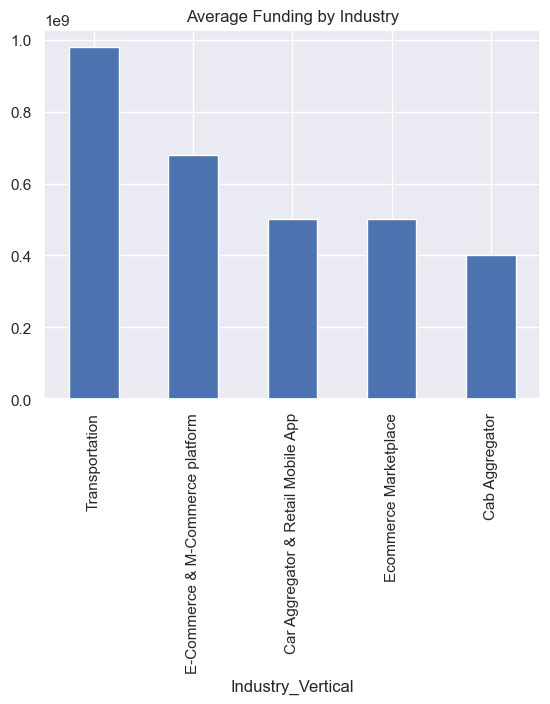

In [139]:
industry_funding = (
    df.groupby("Industry_Vertical")["Amount_in_USD_Clean"].mean()  # gives avarage amount for each industries. 
      .sort_values(ascending=False)                                # for visualization in decending order 
)

industry_funding.head(5).plot(kind="bar")                          # bar plot with top 5 values. 
plt.title("Average Funding by Industry")
plt.show()

**3.3.(b) City-wise funding**

Similar to the above one, we can find the total funding by city, which are less funded. 

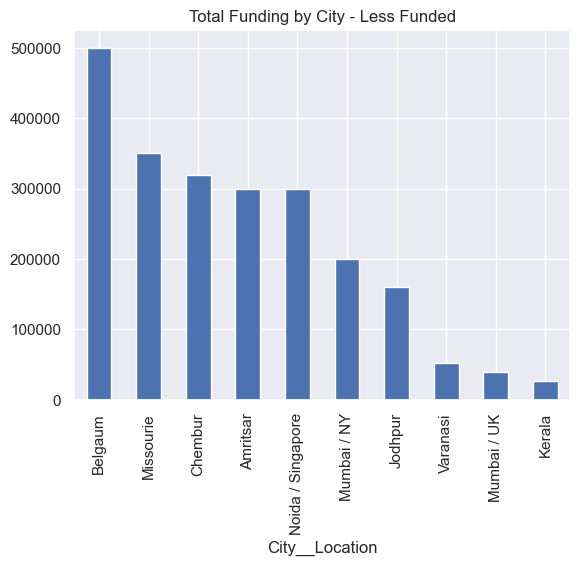

In [140]:
city_funding = (
    df.groupby("City__Location")["Amount_in_USD_Clean"].sum()      # total amount by city. 
      .sort_values(ascending=False)
)

city_funding.tail(10).plot(kind="bar")                             # last 10
plt.title("Total Funding by City - Less Funded")
plt.show()

### 3.4 Multivariate Analysis

A set of statistical methods for analyzing data with multiple variables simultaneously. 

**3.4.(a) Pivot table**

Using pivot table, we are going to find a relationship between different categories, industries and the amount they recieved. 

In [141]:
pivot_table = pd.pivot_table(                 # create pivot table
    df,
    values="Amount_in_USD_Clean",
    index="Industry_Vertical",
    columns="Category",
    aggfunc="sum"                             # aggregates the sum. 
)

pivot_table.head()

Category,Tier-1,Tier-2,Tier-3
Industry_Vertical,,,
360-degree view creating platform,NaN,NaN,1.840230e+07
3D Printer Manufacturer,NaN,NaN,3.000000e+06
AI,NaN,NaN,1.840230e+07
API Workflow platform,NaN,NaN,1.000000e+06
Accounting,NaN,NaN,5.000000e+06


**3.4.(b) Heat map**

Now we visualize a heat map using above pivot table. 

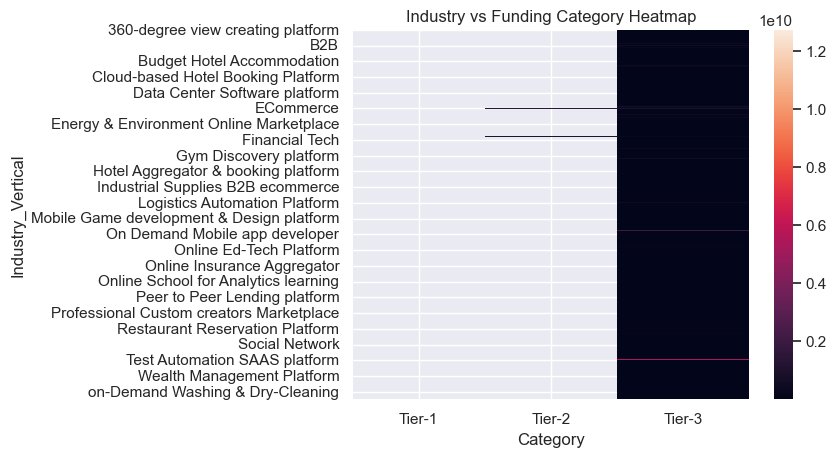

In [142]:
sns.heatmap(pivot_table, annot=False)
plt.title("Industry vs Funding Category Heatmap")
plt.show()

**3.4.(c) Scatter plot**

We can also make a scatter plot for funding amount by category and industry. 

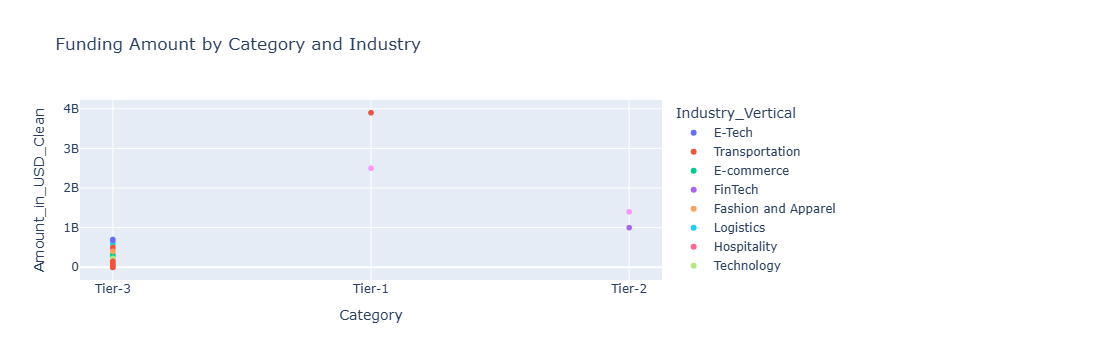

In [143]:
fig = px.scatter(                                                  # create a scatterplot using plotly. 
    df,
    x="Category",
    y="Amount_in_USD_Clean",
    color="Industry_Vertical",
    title="Funding Amount by Category and Industry"
)
fig.show()

### 3.5 More Visualizations

**3.5.(a) Funding category distribution**

By the help of a pie chart, let us visualize the funding category distribution. 

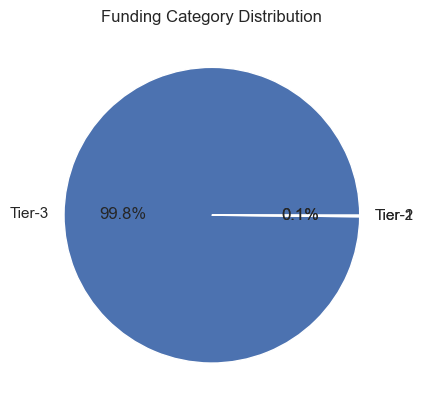

In [144]:
values=df["Category"].value_counts()
plt.pie(values,labels=values.index,autopct="%1.1f%%")
plt.title("Funding Category Distribution")
plt.show()

**3.5.(b) Distribution of funding by category**

A boxplot to visualize the funding distribution by category. 

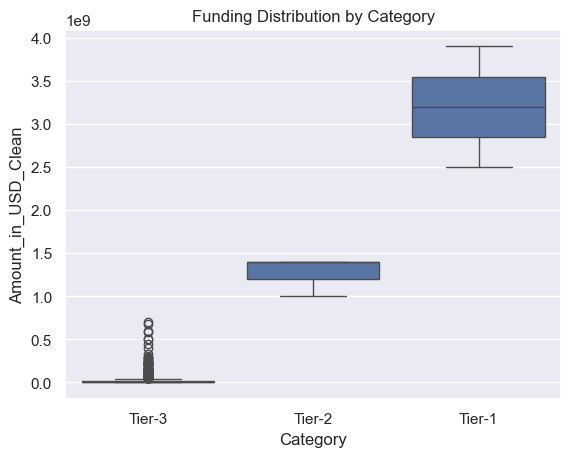

In [148]:
sns.boxplot(data=df, x="Category", y="Amount_in_USD_Clean")
plt.title("Funding Distribution by Category")
plt.show()

**3.5.(c) Funding over time**

Let us have a look at the funding trend over time(yearly), using a line chart. 

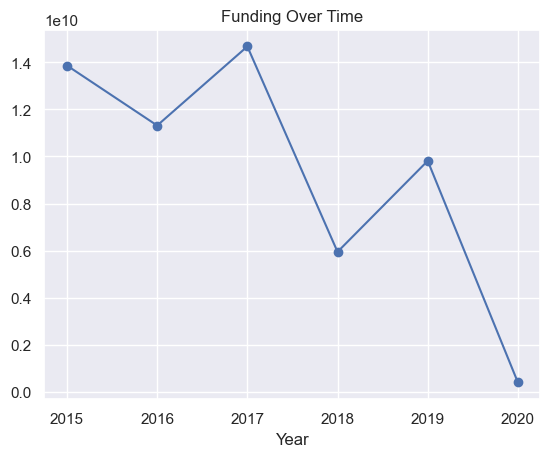

In [154]:
df["year"] = df["Date"].dt.year                                                      # to extract year
yearly_funding = df.groupby("year")["Amount_in_USD_Clean"].sum().reset_index()       # sum funding per year. 
plt.plot(yearly_funding["year"], yearly_funding["Amount_in_USD_Clean"], marker="o")
plt.title("Funding Over Time")
plt.xlabel("Year")
plt.show()

**3.5.(d) Total funding by category and average funding by category**

Now we will side by side analyze average funding by category and total funding by category. 

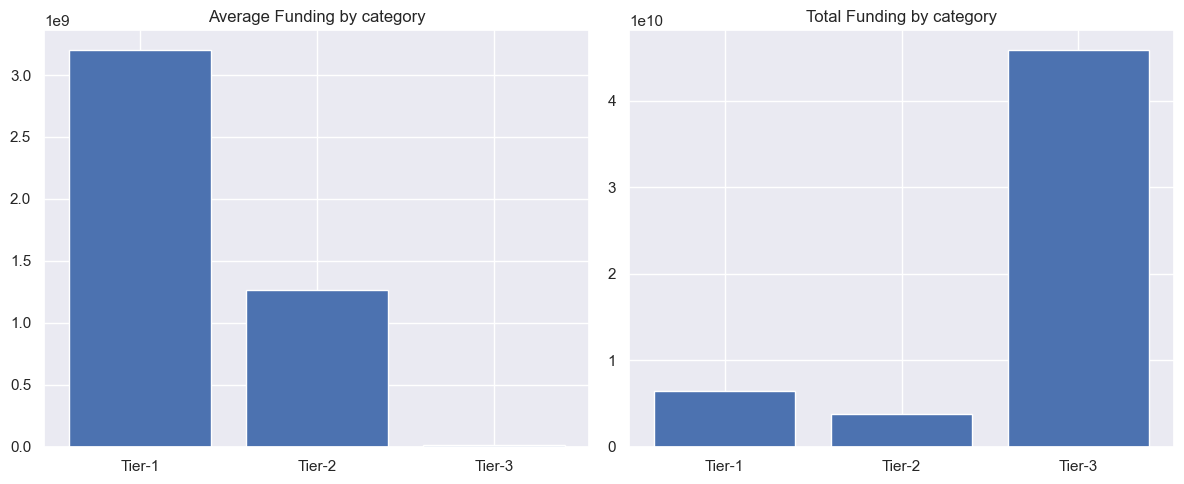

In [160]:
Avg_amount = df.groupby("Category")["Amount_in_USD_Clean"].mean().reset_index()    # grouping categories based on average funding
sum_amount = df.groupby("Category")["Amount_in_USD_Clean"].sum().reset_index()     # grouping categories based on total funding

fig, axes = plt.subplots(1, 2, figsize=(12, 5))                                     # to get charts side by side

axes[0].bar(Avg_amount["Category"], Avg_amount["Amount_in_USD_Clean"])             # first chart
axes[0].set_title("Average Funding by category")

axes[1].bar(sum_amount["Category"], sum_amount["Amount_in_USD_Clean"])             # second chart
axes[1].set_title("Total Funding by category")

plt.tight_layout()
plt.show()